In [1]:
# Imports
import time
import itertools

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from hysys import open_case, dump, members, by_component
from hysys_methanol import cache_objects, run_point

In [23]:
# KNOBS
SMOKE_TEST = True
TEMP_BOUNDS = np.array([220, 280])
PURGE_RATE_BOUNDS = np.array([0.01, 0.05])

In [3]:
# Setup
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\methanol.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case name:        Case
Material streams: 42
Connected in      0.0 s
Objects cached OK:
  solver
  units
  co2in
  h2in
  rin
  rout
  methanol
  purge
  recycle_gas
  reactor
  split
  column
  flare
  recycle
  pressure_cell
  ratio_cell
  h2_index
  co2_index
  meoh_index


In [4]:
def T_purge_sweep():
    PRESSURE = 90 # bar
    RATIO = 3.0 # H2 to CO2
    VOLUME = 19 # m3
    results = []
    all_temp = np.linspace(TEMP_BOUNDS[0], TEMP_BOUNDS[1], 20 if not SMOKE_TEST else 3) # [C]
    all_purge = np.linspace(PURGE_RATE_BOUNDS[0], PURGE_RATE_BOUNDS[1], 5 if not SMOKE_TEST else 3) # [-]

    for T, prg in itertools.product(all_temp, all_purge):
        print("processing", "T", T, "Purge", prg)
        point = dict(temperature=(T, "C"), purge_rate=(prg), pressure=(PRESSURE, "bar"), ratio=(RATIO), volume=(VOLUME, "m3"))
        try:
            results.append(run_point(objects, **point))
        except Exception as e:
            results.append(dict(temperature_set=T, purge_rate_set=prg, converged=False, error=str(e)))

    return results
    
results = T_purge_sweep()

processing T 220.0 Purge 0.01
processing T 220.0 Purge 0.03
processing T 220.0 Purge 0.05
processing T 250.0 Purge 0.01
processing T 250.0 Purge 0.03
processing T 250.0 Purge 0.05
processing T 280.0 Purge 0.01
processing T 280.0 Purge 0.03
processing T 280.0 Purge 0.05


In [14]:
df = pd.DataFrame(results)
df.columns
if not df["converged"].all():
    print("Warning: Not all points converged")

In [15]:
def heatmap(df, value, label, *, x="purge_rate_set", y="temperature_set", levels=6, cmap="viridis", ax=None, title=None):
    """Heatmap of value over (x, y); non-converged cells in grey."""
    _df = df.copy()
    _df["value_plot"] = _df[value].where(_df["converged"])
    grid = _df.pivot(index=y, columns=x, values="value_plot")
    if ax is None:
        _, ax = plt.subplots(1, 1) 
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("0.85")
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=levels, colors="black", linewidths=1)
    ax.clabel(cs, fmt="%.0f")
    ax.set_xlabel("purge-rate [-]")
    ax.set_ylabel("T [$^\\circ{C}$]")
    ax.set_title(title)
    ax.figure.colorbar(mesh, ax=ax, label=label)

    return ax

<Axes: title={'center': 'Methanol Production'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

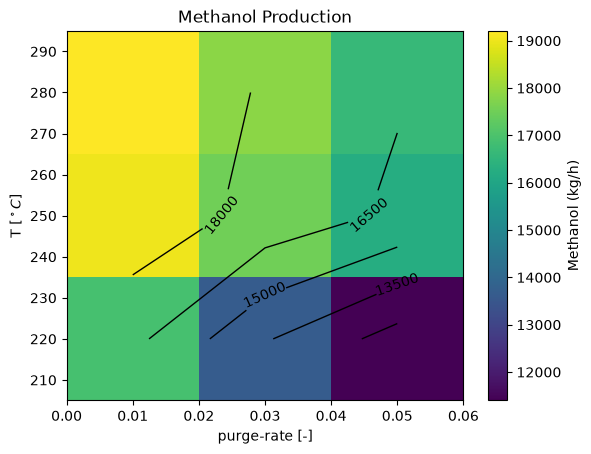

In [16]:
df = pd.DataFrame(results)
heatmap(df, "methanol_kg_h", "Methanol (kg/h)", title="Methanol Production")

<Axes: title={'center': 'Recycle Ratio'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

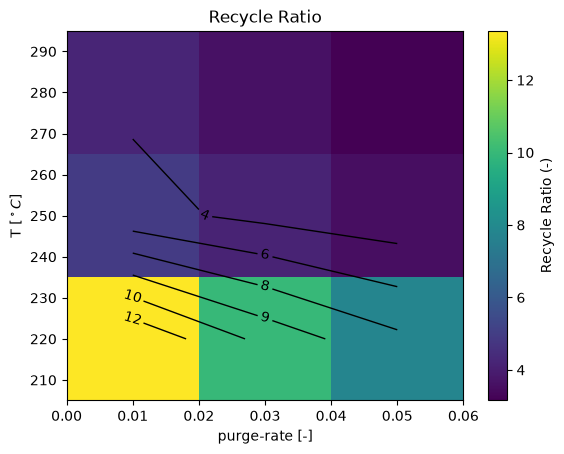

In [17]:
heatmap(df, "recycle_ratio", "Recycle Ratio (-)", title="Recycle Ratio")

<Axes: title={'center': 'Pressure Drop'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

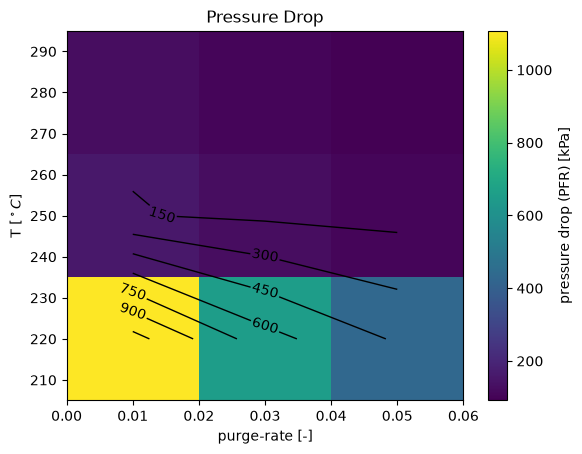

In [18]:
heatmap(df, "reactor_dP_kPa", "pressure drop (PFR) [kPa]", title="Pressure Drop")

# Decomposition Using Surrogates

In [28]:
PAR_DIM = 2 # Number of design parameters (temperature, purge-rate) -> we generate 10x more sobol points for initialization

In [76]:
# NOTE: The below is for the input variable estimation of the Reactor Inlets
U_Hull = dict(Hydrogen=[+np.inf, -np.inf], 
              CO=[+np.inf, -np.inf], 
              CO2=[+np.inf, -np.inf], 
              H2O=[+np.inf, -np.inf], 
              Methanol=[+np.inf, -np.inf], 
              Nitrogen=[+np.inf, -np.inf], 
              )

def update_U_hull(verbose: bool = True):
    """Update the bounds on the input variable hull.
    NOTE: Hull stores absolute molar flows [kmol/s]"""
    rin = objects["rin"]
    T = rin.Temperature.GetValue("C")
    P = rin.Pressure.GetValue("bar")
    F = rin.MolarFlow.GetValue("kgmole/s")
    x = by_component(rin)
    for c in x:
        if c not in U_Hull:
            continue
        molar_flow = x[c] * F
        U_Hull[c][0] = min(U_Hull[c][0], molar_flow)
        U_Hull[c][1] = max(U_Hull[c][1], molar_flow)
    if verbose:
        print(f"Temperature {T:>30.1f} C")
        print(f"Pressure    {P:>30.1f} bar")


In [77]:
def generate_sobol_points(n: int, bounds):
    """
    n: number of points to sample
    """
    d = bounds.shape[1]
    m = int(np.ceil(np.log2(n)))
    sbsam = scipy.stats.qmc.Sobol(d=d, seed=42)
    rand_norm = sbsam.random_base2(m=m) # 2^m points
    pts = rand_norm * (bounds[1] - bounds[0]) + bounds[0]
    return pts[:n]

In [78]:
def characterize_inlet_domain():
    """Step 1) of the methodology (see PP slides)"""
    # TODO: Use the data from samples efficiently as per Benoit's suggestion
    PRESSURE = 90 # bar
    RATIO = 3.0 # H2 to CO2
    VOLUME = 19 # m3
    results = []
    T_bounds = np.array([220, 280]) # [C]

    parameter_bounds = np.array([[TEMP_BOUNDS[0], PURGE_RATE_BOUNDS[0]], # lower bounds
                            [TEMP_BOUNDS[1], PURGE_RATE_BOUNDS[1]]]) # upper bounds
    init_samples = generate_sobol_points(n=PAR_DIM * 10, bounds=parameter_bounds)

    for T, prg in init_samples:
        print("processing", "T", T, "Purge", prg)
        point = dict(temperature=(T, "C"), purge_rate=(prg), pressure=(PRESSURE, "bar"), ratio=(RATIO), volume=(VOLUME, "m3"))
        try:
            results.append(run_point(objects, **point))
            update_U_hull()
        except Exception as e:
            results.append(dict(temperature_set=T, purge_rate_set=prg, converged=False, error=str(e)))

    # return results
characterize_inlet_domain()

processing T 245.86176846176386 Purge 0.04257471889257431
Temperature                          245.9 C
Pressure                              90.0 bar
processing T 277.6947275735438 Purge 0.022456397712230684
Temperature                          277.7 C
Pressure                              90.0 bar
processing T 253.87191522866488 Purge 0.03391337219625711
Temperature                          253.9 C
Pressure                              90.0 bar
processing T 222.10283929482102 Purge 0.011060370840132236
Temperature                          222.1 C
Pressure                              90.0 bar
processing T 234.28403655067086 Purge 0.035587904453277586
Temperature                          234.3 C
Pressure                              90.0 bar
processing T 258.56572959572077 Purge 0.019376138448715212
Temperature                          258.6 C
Pressure                              90.0 bar
processing T 265.5009132064879 Purge 0.04667173657566309
Temperature                          265

In [79]:
U_Hull

{'Hydrogen': [2.2517004580693993, 7.10958163508474],
 'CO': [0.058884126474849245, 0.5036363097137284],
 'CO2': [0.500841572732641, 1.5675825141488278],
 'H2O': [0.008143912245261046, 0.011377291238916946],
 'Methanol': [0.0044305136558353535, 0.018554147117322565],
 'Nitrogen': [0.04506190083179082, 0.10826880274227597]}